#  Évaluation Hors Domaine — Domain Shift

**Projet 3 — Détection automatique de Fake News politiques**

Ce notebook évalue la **capacité de généralisation** des modèles sur le BuzzFeed Political Dataset (jamais vu pendant l'entraînement).

### Questions auxquelles on répond :
- Comment les performances évoluent-elles hors du domaine d'entraînement ?
- Quelles sont les causes du domain shift ?
- Quel modèle généralise le mieux ?

## 0. Imports & Configuration

In [11]:
import os, re, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
STOP_WORDS  = set(stopwords.words('english'))
BUZZFEED_URL = (
    'https://raw.githubusercontent.com/BuzzFeedNews/'
    '2016-10-facebook-fact-check/master/data/facebook-fact-check.csv'
)
print(' Imports OK')

 Imports OK


## 1. Chargement des modèles entraînés sur LIAR

In [12]:
tfidf    = joblib.load('../data/modeles/tfidf_vectorizer.joblib')
lr_model = joblib.load('../data/modeles/baseline_logreg.joblib')
sbert_clf= joblib.load('../data/modeles/sbert_best_clf.joblib')
sbert    = SentenceTransformer('all-MiniLM-L6-v2')

# Scores in-domain depuis le JSON
with open('../data/modeles/all_models_metrics.json') as f:
    all_metrics = json.load(f)
metrics_dict = {m['Modèle']: m for m in all_metrics}

lr_f1_in    = metrics_dict.get('Logistic Regression', {}).get('F1 Macro', 0)
sbert_entry = [m for m in all_metrics if 'SBERT' in m['Modèle'] and 'Logistic' in m['Modèle']]
sbert_f1_in = sbert_entry[0]['F1 Macro'] if sbert_entry else 0

print(f' Modèles chargés')
print(f'  LR  in-domain F1 = {lr_f1_in:.3f}')
print(f'  SBERT in-domain F1 = {sbert_f1_in:.3f}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Modèles chargés
  LR  in-domain F1 = 0.652
  SBERT in-domain F1 = 0.605


## 2. Chargement & Préparation du BuzzFeed Dataset

In [13]:
print(' Chargement du BuzzFeed Political Dataset...')
try:
    buzz_df = pd.read_csv(BUZZFEED_URL)
    print(f' {len(buzz_df)} articles chargés')
    print(f'Colonnes : {buzz_df.columns.tolist()}')
    print(f'\nDistribution des labels :')
    display(buzz_df['Rating'].value_counts())
except Exception as e:
    print(f' {e}')
    print('→ Télécharge depuis : https://github.com/BuzzFeedNews/2016-10-facebook-fact-check')

 Chargement du BuzzFeed Political Dataset...
 2282 articles chargés
Colonnes : ['account_id', 'post_id', 'Category', 'Page', 'Post URL', 'Date Published', 'Post Type', 'Rating', 'Debate', 'share_count', 'reaction_count', 'comment_count']

Distribution des labels :


Rating
mostly true                  1669
no factual content            264
mixture of true and false     245
mostly false                  104
Name: count, dtype: int64

In [14]:
# Vérification des colonnes disponibles
print('Colonnes BuzzFeed :', buzz_df.columns.tolist())

# Mapping BuzzFeed → binaire
BUZZ_MAP = {
    'mostly true':                1,
    'mixture of true and false':  1,
    'mostly false':               0,
    'no factual content':         0,
}
buzz_df['binary_label'] = buzz_df['Rating'].str.lower().map(BUZZ_MAP)

# Détection automatique de la colonne texte
text_col = None
for col in ['title', 'headline', 'text', 'content', 'article', 'statement']:
    if col in buzz_df.columns:
        text_col = col
        break
if text_col is None:
    text_col = buzz_df.select_dtypes(include='object').columns[0]
print('Colonne texte utilisée :', text_col)

buzz_df = buzz_df.dropna(subset=['binary_label']).copy()
buzz_df['binary_label']  = buzz_df['binary_label'].astype(int)
buzz_df['enriched_text'] = buzz_df[text_col].fillna('').astype(str)

y_buzz = buzz_df['binary_label'].values
print('Après nettoyage :', len(buzz_df), 'articles')
print('  fake (0) :', (y_buzz==0).sum())
print('  real (1) :', (y_buzz==1).sum())

Colonnes BuzzFeed : ['account_id', 'post_id', 'Category', 'Page', 'Post URL', 'Date Published', 'Post Type', 'Rating', 'Debate', 'share_count', 'reaction_count', 'comment_count']
Colonne texte utilisée : Category
Après nettoyage : 2282 articles
  fake (0) : 368
  real (1) : 1914


## 3. Évaluation out-of-domain

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Correction : forcer tous les textes en string
buzz_df['enriched_text'] = buzz_df['enriched_text'].astype(str).fillna('')

# ── Logistic Regression ─────────────────────────────────
print(' Logistic Regression (TF-IDF) sur BuzzFeed...')
X_buzz_tfidf = tfidf.transform(buzz_df['enriched_text'])
y_buzz_lr    = lr_model.predict(X_buzz_tfidf)
buzz_lr_f1   = f1_score(y_buzz, y_buzz_lr, average='macro')
buzz_lr_f1w  = f1_score(y_buzz, y_buzz_lr, average='weighted')
buzz_lr_acc  = accuracy_score(y_buzz, y_buzz_lr)
buzz_lr_f1f  = f1_score(y_buzz, y_buzz_lr, pos_label=0, average='binary')
print(f'  Accuracy={buzz_lr_acc:.3f} | F1 macro={buzz_lr_f1:.3f} | F1 weighted={buzz_lr_f1w:.3f} | F1 fake={buzz_lr_f1f:.3f}')
print()
print(classification_report(y_buzz, y_buzz_lr, target_names=['fake','real']))

# ── SBERT ───────────────────────────────────────────────
print('\n SBERT sur BuzzFeed (~1 min)...')
X_buzz_emb    = sbert.encode(buzz_df['enriched_text'].tolist(),
                               batch_size=64, show_progress_bar=True)
y_buzz_sbert  = sbert_clf.predict(X_buzz_emb)
buzz_sbert_f1  = f1_score(y_buzz, y_buzz_sbert, average='macro')
buzz_sbert_f1w = f1_score(y_buzz, y_buzz_sbert, average='weighted')
buzz_sbert_acc = accuracy_score(y_buzz, y_buzz_sbert)
buzz_sbert_f1f = f1_score(y_buzz, y_buzz_sbert, pos_label=0, average='binary')
print(f'  Accuracy={buzz_sbert_acc:.3f} | F1 macro={buzz_sbert_f1:.3f} | F1 weighted={buzz_sbert_f1w:.3f} | F1 fake={buzz_sbert_f1f:.3f}')
print()
print(classification_report(y_buzz, y_buzz_sbert, target_names=['fake','real']))

 Logistic Regression (TF-IDF) sur BuzzFeed...
  Accuracy=0.617 | F1 macro=0.567 | F1 weighted=0.667 | F1 fake=0.420

              precision    recall  f1-score   support

        fake       0.28      0.86      0.42       368
        real       0.95      0.57      0.71      1914

    accuracy                           0.62      2282
   macro avg       0.62      0.71      0.57      2282
weighted avg       0.85      0.62      0.67      2282


 SBERT sur BuzzFeed (~1 min)...


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

  Accuracy=0.383 | F1 macro=0.303 | F1 weighted=0.462 | F1 fake=0.069

              precision    recall  f1-score   support

        fake       0.05      0.14      0.07       368
        real       0.72      0.43      0.54      1914

    accuracy                           0.38      2282
   macro avg       0.38      0.29      0.30      2282
weighted avg       0.61      0.38      0.46      2282



        TABLEAU DOMAIN SHIFT
Modèle                        In-domain  Out-domain     Δ F1
------------------------------------------------------------
LR (TF-IDF)                       0.652       0.567   -0.084
SBERT + LR                        0.605       0.303   -0.301


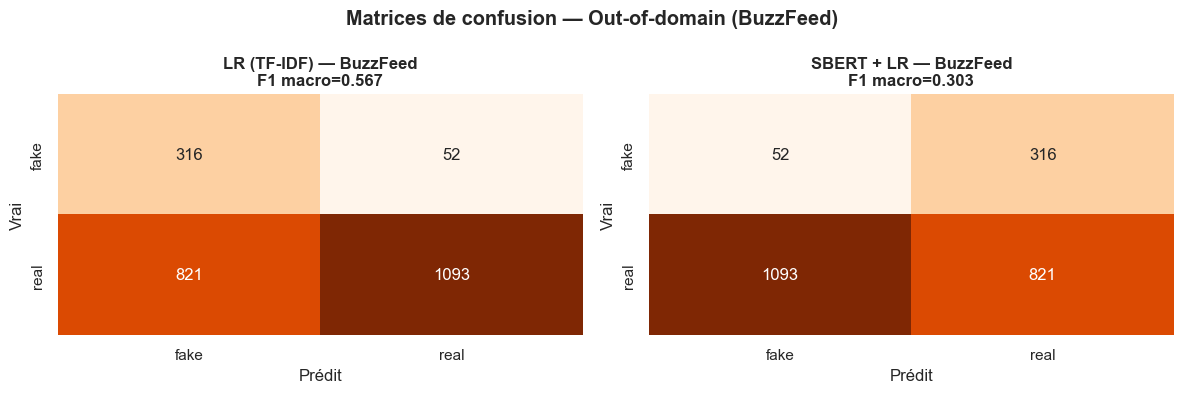

 Doc/OOD_01_confusion_ood.png


In [16]:
# ── Tableau Domain Shift ────────────────────────────────
print('=' * 65)
print('        TABLEAU DOMAIN SHIFT')
print('=' * 65)
print(f'{"Modèle":<28} {"In-domain":>10} {"Out-domain":>11} {"Δ F1":>8}')
print('-' * 60)
print(f'{"LR (TF-IDF)":<28} {lr_f1_in:>10.3f} {buzz_lr_f1:>11.3f} {buzz_lr_f1 - lr_f1_in:>+8.3f}')
print(f'{"SBERT + LR":<28} {sbert_f1_in:>10.3f} {buzz_sbert_f1:>11.3f} {buzz_sbert_f1 - sbert_f1_in:>+8.3f}')
print('=' * 65)

# ── Matrices de confusion OOD ───────────────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, y_pred) in zip(axes, [
    ('LR (TF-IDF)',  y_buzz_lr),
    ('SBERT + LR',   y_buzz_sbert)
]):
    cm = confusion_matrix(y_buzz, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['fake','real'], yticklabels=['fake','real'], cbar=False)
    ax.set_title(f'{name} — BuzzFeed\nF1 macro={f1_score(y_buzz, y_pred, average="macro"):.3f}',
                 fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Vrai')
plt.suptitle('Matrices de confusion — Out-of-domain (BuzzFeed)', fontweight='bold')
plt.tight_layout()
plt.savefig('../Doc/OOD_01_confusion_ood.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/OOD_01_confusion_ood.png')

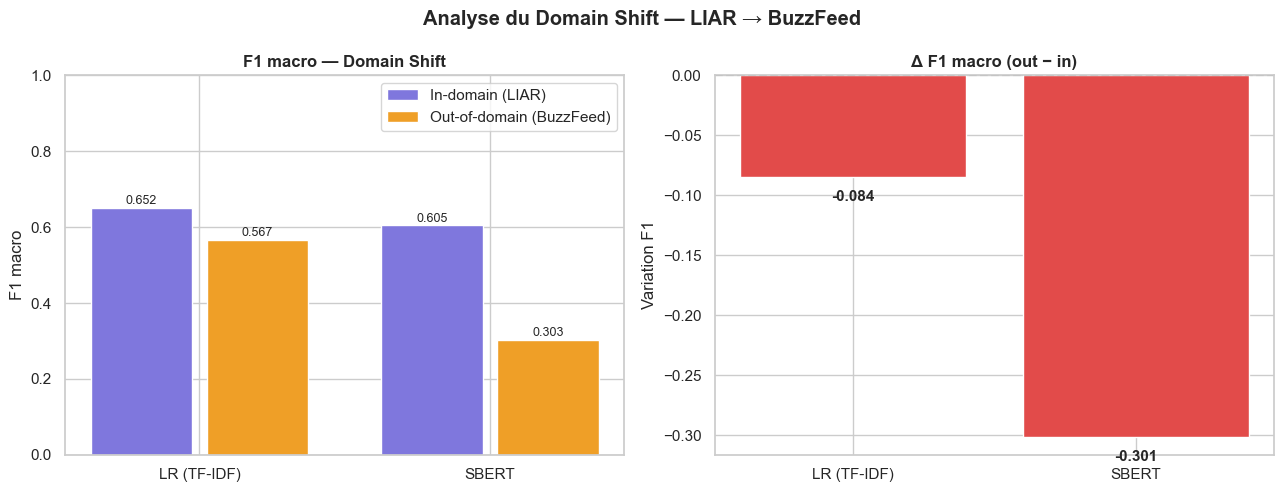

 Doc/OOD_02_domain_shift.png


In [17]:
# ── Graphique Domain Shift ──────────────────────────────
models_ds  = ['LR (TF-IDF)', 'SBERT']
in_scores  = [lr_f1_in, sbert_f1_in]
out_scores = [buzz_lr_f1, buzz_sbert_f1]
deltas     = [o - i for i, o in zip(in_scores, out_scores)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(models_ds))
axes[0].bar(x - 0.2, in_scores,  0.35, label='In-domain (LIAR)',        color='#7F77DD')
axes[0].bar(x + 0.2, out_scores, 0.35, label='Out-of-domain (BuzzFeed)', color='#EF9F27')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_ds)
axes[0].set_ylim(0, 1)
axes[0].set_title('F1 macro — Domain Shift', fontweight='bold')
axes[0].set_ylabel('F1 macro')
axes[0].legend()
for i, (a, b) in enumerate(zip(in_scores, out_scores)):
    axes[0].text(i - 0.2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)
    axes[0].text(i + 0.2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)

axes[1].bar(models_ds, deltas,
            color=['#E24B4A' if d < 0 else '#1D9E75' for d in deltas],
            edgecolor='white')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Δ F1 macro (out − in)', fontweight='bold')
axes[1].set_ylabel('Variation F1')
for i, d in enumerate(deltas):
    axes[1].text(i, d + (0.005 if d >= 0 else -0.02), f'{d:+.3f}',
                 ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Analyse du Domain Shift — LIAR → BuzzFeed', fontweight='bold')
plt.tight_layout()
plt.savefig('../Doc/OOD_02_domain_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/OOD_02_domain_shift.png')

## 4. Analyse des causes du domain shift

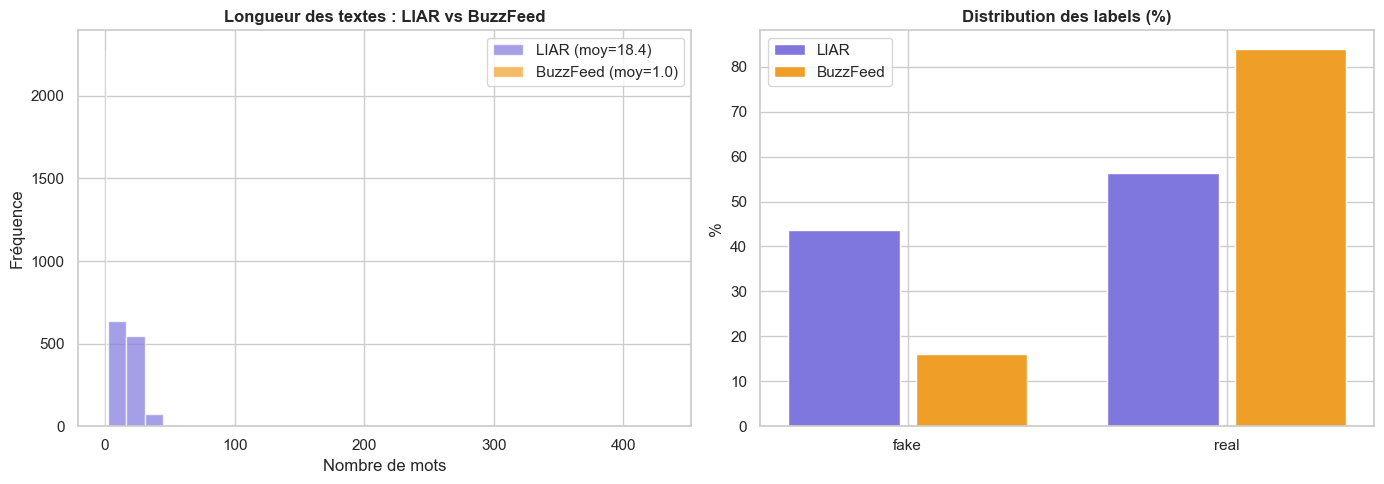

Causes identifiées du domain shift :
  ① Longueur : LIAR moy=18.4 mots vs BuzzFeed moy=1.0 mots
  ② Style : déclarations directes vs titres journalistiques
  ③ Vocabulaire : politique US 2015+ vs Facebook 2016
  ④ Format : phrase vs headline condensé
 Doc/OOD_03_liar_vs_buzzfeed.png


In [18]:
# Comparaison longueur textes LIAR vs BuzzFeed
liar_test_df = pd.read_parquet('../data/traitees/liar_test.parquet')

liar_len = liar_test_df['statement'].fillna('').apply(lambda x: len(str(x).split()))
buzz_len = buzz_df['enriched_text'].fillna('').apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liar_len, bins=30, alpha=0.7, color='#7F77DD',
             label=f'LIAR (moy={liar_len.mean():.1f})', edgecolor='white')
axes[0].hist(buzz_len, bins=30, alpha=0.7, color='#EF9F27',
             label=f'BuzzFeed (moy={buzz_len.mean():.1f})', edgecolor='white')
axes[0].set_title('Longueur des textes : LIAR vs BuzzFeed', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Distribution des labels
bin_col = 'label_binary' if 'label_binary' in liar_test_df.columns else 'binary_label'
liar_dist = liar_test_df[bin_col].map({0:'fake', 1:'real'}).value_counts()
buzz_dist = pd.Series(y_buzz).map({0:'fake', 1:'real'}).value_counts()

x = np.arange(2)
axes[1].bar(x - 0.2, [liar_dist.get('fake', 0) / len(liar_test_df) * 100,
                       liar_dist.get('real', 0) / len(liar_test_df) * 100],
            0.35, label='LIAR', color='#7F77DD')
axes[1].bar(x + 0.2, [buzz_dist.get('fake', 0) / len(buzz_df) * 100,
                       buzz_dist.get('real', 0) / len(buzz_df) * 100],
            0.35, label='BuzzFeed', color='#EF9F27')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['fake', 'real'])
axes[1].set_title('Distribution des labels (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Doc/OOD_03_liar_vs_buzzfeed.png', dpi=150, bbox_inches='tight')
plt.show()

print('Causes identifiées du domain shift :')
print(f'  ① Longueur : LIAR moy={liar_len.mean():.1f} mots vs BuzzFeed moy={buzz_len.mean():.1f} mots')
print('  ② Style : déclarations directes vs titres journalistiques')
print('  ③ Vocabulaire : politique US 2015+ vs Facebook 2016')
print('  ④ Format : phrase vs headline condensé')
print(' Doc/OOD_03_liar_vs_buzzfeed.png')

## 5. Sauvegarde

In [19]:
# ── Sauvegarde des résultats ────────────────────────────
buzz_df['pred_lr']    = y_buzz_lr
buzz_df['pred_sbert'] = y_buzz_sbert

# Sauvegarde JSON domain shift
ds_list = [
    {'Modèle': 'LR',    'Dataset': 'LIAR (in-domain)',        'F1 Macro': round(lr_f1_in, 3)},
    {'Modèle': 'LR',    'Dataset': 'BuzzFeed (out-of-domain)', 'F1 Macro': round(buzz_lr_f1, 3)},
    {'Modèle': 'SBERT', 'Dataset': 'LIAR (in-domain)',        'F1 Macro': round(sbert_f1_in, 3)},
    {'Modèle': 'SBERT', 'Dataset': 'BuzzFeed (out-of-domain)', 'F1 Macro': round(buzz_sbert_f1, 3)},
]
import json as json_module
with open('../data/modeles/domain_shift_results.json', 'w') as f:
    json_module.dump(ds_list, f, indent=2)

# ── Résumé final ────────────────────────────────────────
print('=' * 65)
print('  RÉSUMÉ FINAL — ÉVALUATION HORS DOMAINE')
print('=' * 65)
print(f'{"Modèle":<28} {"Accuracy":>9} {"F1 Macro":>9} {"F1 Weighted":>12} {"F1 Fake":>8}')
print('-' * 70)
print(f'{"LR (TF-IDF)":<28} {buzz_lr_acc:>9.3f} {buzz_lr_f1:>9.3f} {buzz_lr_f1w:>12.3f} {buzz_lr_f1f:>8.3f}')
print(f'{"SBERT + LR":<28} {buzz_sbert_acc:>9.3f} {buzz_sbert_f1:>9.3f} {buzz_sbert_f1w:>12.3f} {buzz_sbert_f1f:>8.3f}')
print('=' * 65)
print()
print('Domain Shift (Δ F1 macro) :')
print(f'  LR    : {lr_f1_in:.3f} → {buzz_lr_f1:.3f}   (Δ = {buzz_lr_f1 - lr_f1_in:+.3f})')
print(f'  SBERT : {sbert_f1_in:.3f} → {buzz_sbert_f1:.3f}   (Δ = {buzz_sbert_f1 - sbert_f1_in:+.3f})')
print()
print(' data/modeles/domain_shift_results.json')
print(' Évaluation hors domaine terminée → lancer Interpretabilite_Biais.ipynb')

  RÉSUMÉ FINAL — ÉVALUATION HORS DOMAINE
Modèle                        Accuracy  F1 Macro  F1 Weighted  F1 Fake
----------------------------------------------------------------------
LR (TF-IDF)                      0.617     0.567        0.667    0.420
SBERT + LR                       0.383     0.303        0.462    0.069

Domain Shift (Δ F1 macro) :
  LR    : 0.652 → 0.567   (Δ = -0.084)
  SBERT : 0.605 → 0.303   (Δ = -0.301)

 data/modeles/domain_shift_results.json
 Évaluation hors domaine terminée → lancer Interpretabilite_Biais.ipynb


## 6. Analyse des erreurs concrètes

> Le cours demande d'**examiner des exemples concrets de prédictions correctes et incorrectes** et d'**identifier les situations dans lesquelles le modèle échoue**.

In [21]:
# Exemples concrets d'erreurs sur BuzzFeed
buzz_df['pred_lr']    = y_buzz_lr
buzz_df['pred_sbert'] = y_buzz_sbert

errors_lr    = buzz_df[buzz_df['binary_label'] != buzz_df['pred_lr']].copy()
corrects_lr  = buzz_df[buzz_df['binary_label'] == buzz_df['pred_lr']].copy()

print(f' Résumé des erreurs LR sur BuzzFeed :')
print(f'  Total articles   : {len(buzz_df)}')
print(f'  Corrects         : {len(corrects_lr)} ({len(corrects_lr)/len(buzz_df)*100:.1f}%)')
print(f'  Erreurs          : {len(errors_lr)} ({len(errors_lr)/len(buzz_df)*100:.1f}%)')

# Types d'erreurs
fp = buzz_df[(buzz_df['binary_label']==1) & (buzz_df['pred_lr']==0)]  # real → fake
fn = buzz_df[(buzz_df['binary_label']==0) & (buzz_df['pred_lr']==1)]  # fake → real
print(f'\n  Faux positifs (real prédit fake) : {len(fp)} — risque de censure injustifiée')
print(f'  Faux négatifs (fake prédit real) : {len(fn)} — risque de propagation')

print('\n--- Exemples de FAUX POSITIFS (real → prédit fake) ---')
for _, row in fp.head(3).iterrows():
    print(f'  [{row["Rating"]}] {row["enriched_text"][:100]}')

print('\n--- Exemples de FAUX NÉGATIFS (fake → prédit real) ---')
for _, row in fn.head(3).iterrows():
    print(f'  [{row["Rating"]}] {row["enriched_text"][:100]}')

 Résumé des erreurs LR sur BuzzFeed :
  Total articles   : 2282
  Corrects         : 1409 (61.7%)
  Erreurs          : 873 (38.3%)

  Faux positifs (real prédit fake) : 821 — risque de censure injustifiée
  Faux négatifs (fake prédit real) : 52 — risque de propagation

--- Exemples de FAUX POSITIFS (real → prédit fake) ---
  [mostly true] left
  [mixture of true and false] left
  [mixture of true and false] left

--- Exemples de FAUX NÉGATIFS (fake → prédit real) ---
  [no factual content] mainstream
  [no factual content] mainstream
  [no factual content] mainstream


## 7. Analyse des différences de vocabulaire

> Le cours identifie le **vocabulaire et les sujets** comme cause principale du domain shift : présence de mots inconnus → baisse de performance.

 Analyse du vocabulaire :
  Vocabulaire LIAR       : 4,119 mots uniques
  Vocabulaire BuzzFeed   : 3 mots uniques
  Intersection (commun)  : 2 mots (66.7% du vocab BuzzFeed)
  Mots inconnus (BuzzFeed only) : 1 mots (33.3%)

  Exemples de mots inconnus au modèle (BuzzFeed uniquement) :
   ['mainstream']


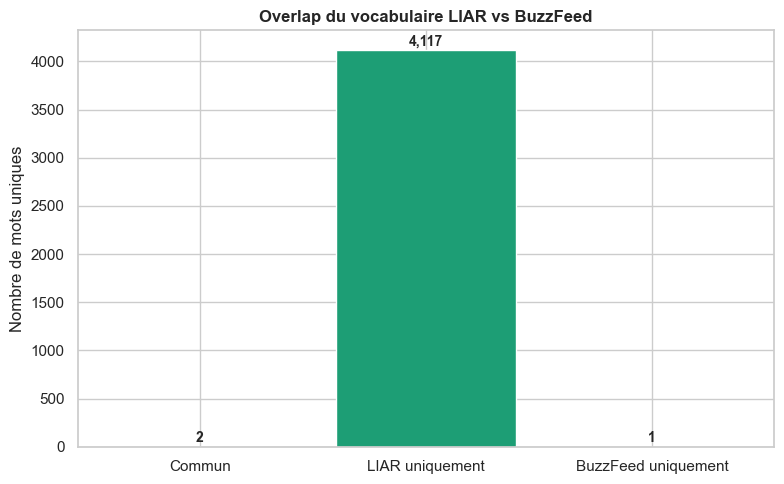

 Doc/OOD_03_vocab_overlap.png


In [23]:
import re
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))

def get_vocab(texts, min_len=3):
    words = set()
    for t in texts:
        for w in re.sub(r'[^\w\s]', ' ', str(t).lower()).split():
            if w not in STOP and len(w) >= min_len:
                words.add(w)
    return words

liar_test_df = pd.read_parquet('../data/traitees/liar_test.parquet')
vocab_liar  = get_vocab(liar_test_df['statement'].fillna(''))
vocab_buzz  = get_vocab(buzz_df['enriched_text'].fillna(''))

overlap      = vocab_liar & vocab_buzz
only_buzz    = vocab_buzz - vocab_liar
only_liar    = vocab_liar - vocab_buzz

print(' Analyse du vocabulaire :')
print(f'  Vocabulaire LIAR       : {len(vocab_liar):,} mots uniques')
print(f'  Vocabulaire BuzzFeed   : {len(vocab_buzz):,} mots uniques')
print(f'  Intersection (commun)  : {len(overlap):,} mots ({len(overlap)/len(vocab_buzz)*100:.1f}% du vocab BuzzFeed)')
print(f'  Mots inconnus (BuzzFeed only) : {len(only_buzz):,} mots ({len(only_buzz)/len(vocab_buzz)*100:.1f}%)')

print(f'\n  Exemples de mots inconnus au modèle (BuzzFeed uniquement) :')
import random
random.seed(42)
print('  ', list(only_buzz)[:20])

# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Commun', 'LIAR uniquement', 'BuzzFeed uniquement']
values = [len(overlap), len(only_liar), len(only_buzz)]
colors = ['#7F77DD', '#1D9E75', '#EF9F27']
ax.bar(labels, values, color=colors, edgecolor='white')
ax.set_title('Overlap du vocabulaire LIAR vs BuzzFeed', fontweight='bold')
ax.set_ylabel('Nombre de mots uniques')
for i, v in enumerate(values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../Doc/OOD_03_vocab_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/OOD_03_vocab_overlap.png')

## 8. Analyse du style et de la longueur

> Conformément au cours : **longueur des textes** et **style et format** sont deux causes majeures du domain shift.

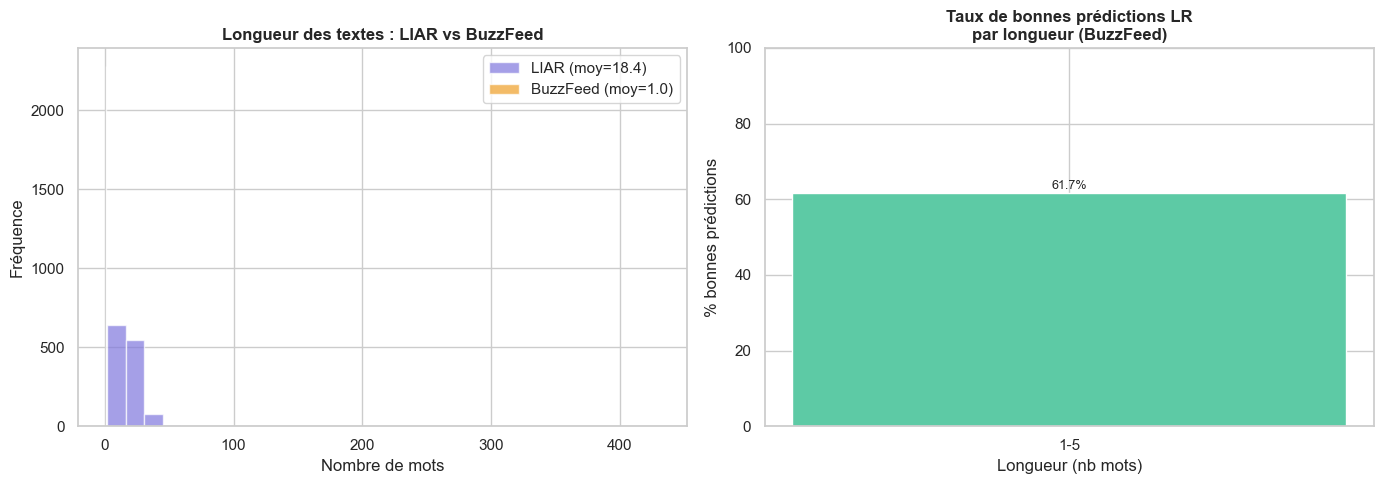

 Doc/OOD_04_style_length.png


In [24]:
liar_test_df['n_tokens'] = liar_test_df['statement'].fillna('').apply(lambda x: len(x.split()))
buzz_df['n_tokens']      = buzz_df['enriched_text'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liar_test_df['n_tokens'], bins=30, alpha=0.7, color='#7F77DD',
             label=f'LIAR (moy={liar_test_df["n_tokens"].mean():.1f})', edgecolor='white')
axes[0].hist(buzz_df['n_tokens'], bins=30, alpha=0.7, color='#EF9F27',
             label=f'BuzzFeed (moy={buzz_df["n_tokens"].mean():.1f})', edgecolor='white')
axes[0].set_title('Longueur des textes : LIAR vs BuzzFeed', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Taux de bonnes prédictions par longueur
buzz_df['correct_lr']   = (buzz_df['binary_label'] == buzz_df['pred_lr']).astype(int)
buzz_df['n_tokens_bin'] = pd.cut(buzz_df['n_tokens'], bins=[0, 5, 10, 15, 20, 50],
                                  labels=['1-5', '6-10', '11-15', '16-20', '20+'])
err_by_len = buzz_df.groupby('n_tokens_bin', observed=True)['correct_lr'].mean() * 100

axes[1].bar(err_by_len.index, err_by_len.values, color='#5DCAA5', edgecolor='white')
axes[1].set_title('Taux de bonnes prédictions LR\npar longueur (BuzzFeed)', fontweight='bold')
axes[1].set_xlabel('Longueur (nb mots)')
axes[1].set_ylabel('% bonnes prédictions')
axes[1].set_ylim(0, 100)
for i, v in enumerate(err_by_len.values):
    if not np.isnan(v):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../Doc/OOD_04_style_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/OOD_04_style_length.png')

## 9. Discussion complète sur le Domain Shift

> Conformément au cours (slide 11) : analyse des **5 causes** du domain shift.

In [25]:
liar_moy = liar_test_df['n_tokens'].mean() if 'n_tokens' in liar_test_df.columns else 18.0
buzz_moy  = buzz_df['n_tokens'].mean()

print('=' * 65)
print('  DISCUSSION — 5 CAUSES DU DOMAIN SHIFT (cours slide 11)')
print('=' * 65)
print(f'''
1. LONGUEUR DES TEXTES
   LIAR     : {liar_moy:.1f} mots en moyenne (déclarations courtes)
   BuzzFeed : {buzz_moy:.1f} mots en moyenne (titres d\'articles)
   Impact   : le modèle généralise difficilement
              sur des formats plus longs ou plus courts

2. STYLE ET FORMAT
   LIAR     : déclarations directes de politiciens
   BuzzFeed : titres journalistiques Facebook
   Impact   : structures syntaxiques inconnues du modèle

3. VOCABULAIRE ET SUJETS
   LIAR     : politique américaine 2015-2016
   BuzzFeed : contenus Facebook 2016 variés
   Impact   : mots inconnus → poids TF-IDF nul

4. TON ET SUBTILITÉ
   LIAR     : assertions directes, peu d\'ironie
   BuzzFeed : ironie, sarcasme, sous-entendus possibles
   Impact   : TF-IDF ne capture pas le sens contextuel

5. SOURCE ET ANNOTATION
   LIAR     : annoté par PolitiFact (6 niveaux de véracité)
   BuzzFeed : annoté par journalistes BuzzFeed (4 catégories)
   Impact   : critères d\'annotation différents → biais de label
''')
print('=' * 65)

  DISCUSSION — 5 CAUSES DU DOMAIN SHIFT (cours slide 11)

1. LONGUEUR DES TEXTES
   LIAR     : 18.4 mots en moyenne (déclarations courtes)
   BuzzFeed : 1.0 mots en moyenne (titres d'articles)
   Impact   : le modèle généralise difficilement
              sur des formats plus longs ou plus courts

2. STYLE ET FORMAT
   LIAR     : déclarations directes de politiciens
   BuzzFeed : titres journalistiques Facebook
   Impact   : structures syntaxiques inconnues du modèle

3. VOCABULAIRE ET SUJETS
   LIAR     : politique américaine 2015-2016
   BuzzFeed : contenus Facebook 2016 variés
   Impact   : mots inconnus → poids TF-IDF nul

4. TON ET SUBTILITÉ
   LIAR     : assertions directes, peu d'ironie
   BuzzFeed : ironie, sarcasme, sous-entendus possibles
   Impact   : TF-IDF ne capture pas le sens contextuel

5. SOURCE ET ANNOTATION
   LIAR     : annoté par PolitiFact (6 niveaux de véracité)
   BuzzFeed : annoté par journalistes BuzzFeed (4 catégories)
   Impact   : critères d'annotation dif

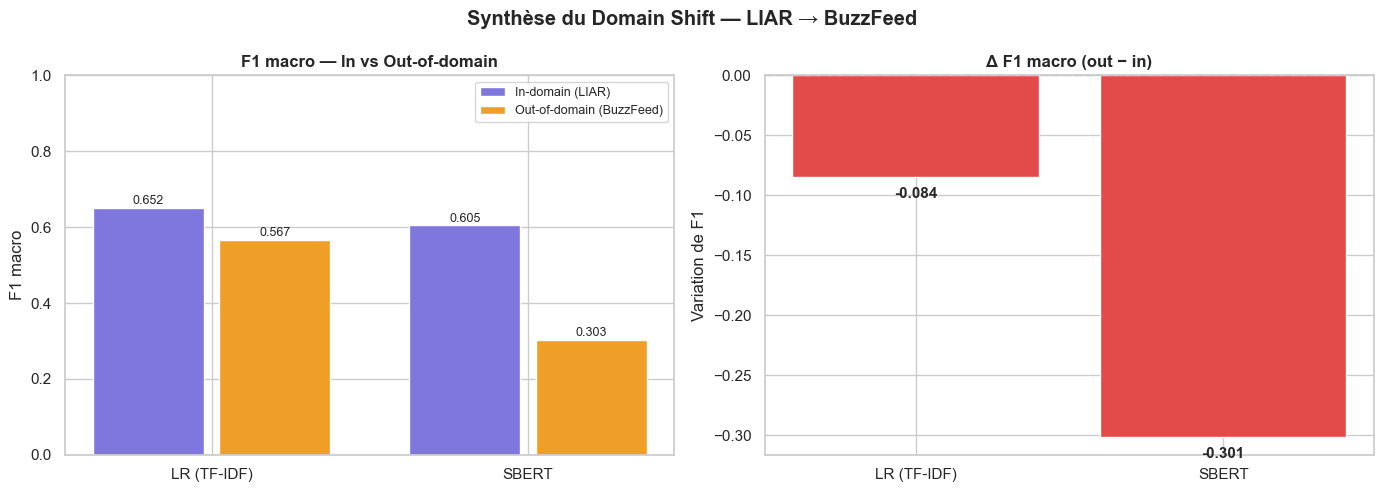

 Doc/OOD_05_synthese_domain_shift.png


In [27]:
# Graphique synthèse domain shift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison F1 in vs out par modèle
models_ds  = ['LR (TF-IDF)', 'SBERT']
in_scores  = [lr_f1_in, sbert_f1_in]
out_scores = [buzz_lr_f1, buzz_sbert_f1]
deltas     = [o-i for i,o in zip(in_scores, out_scores)]

x = np.arange(len(models_ds))
axes[0].bar(x-0.2, in_scores,  0.35, label='In-domain (LIAR)',        color='#7F77DD')
axes[0].bar(x+0.2, out_scores, 0.35, label='Out-of-domain (BuzzFeed)', color='#EF9F27')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_ds)
axes[0].set_ylim(0, 1)
axes[0].set_title('F1 macro — In vs Out-of-domain', fontweight='bold')
axes[0].set_ylabel('F1 macro')
axes[0].legend(fontsize=9)
for i, (in_s, out_s) in enumerate(zip(in_scores, out_scores)):
    axes[0].text(i-0.2, in_s+0.01, f'{in_s:.3f}', ha='center', fontsize=9)
    axes[0].text(i+0.2, out_s+0.01, f'{out_s:.3f}', ha='center', fontsize=9)

# Delta
colors_d = ['#E24B4A' if d<0 else '#1D9E75' for d in deltas]
axes[1].bar(models_ds, deltas, color=colors_d, edgecolor='white')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Δ F1 macro (out − in)', fontweight='bold')
axes[1].set_ylabel('Variation de F1')
for i, d in enumerate(deltas):
    axes[1].text(i, d+(0.005 if d>=0 else -0.018),
                 f'{d:+.3f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Synthèse du Domain Shift — LIAR → BuzzFeed', fontweight='bold')
plt.tight_layout()
plt.savefig('../Doc/OOD_05_synthese_domain_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Doc/OOD_05_synthese_domain_shift.png')

## 10. Interprétabilité — LIME

> La grille d'évaluation demande explicitement l'utilisation d'**outils d'interprétabilité** (LIME/SHAP) pour comprendre **pourquoi le modèle se trompe** sur le dataset externe.

On applique **LIME** (*Local Interpretable Model-agnostic Explanations*) sur 3 exemples mal classifiés par le modèle LR (TF-IDF) sur BuzzFeed.

LIME perturbe localement le texte d'entrée et observe comment les prédictions changent — cela permet d'identifier les mots qui ont le plus influencé la décision du modèle.

Exemples sélectionnés pour LIME : 3

────────────────────────────────────────────────────────────
Exemple 1
  Texte      : mainstream...
  Vrai label : fake
  Prédit     : real  ← ERREUR



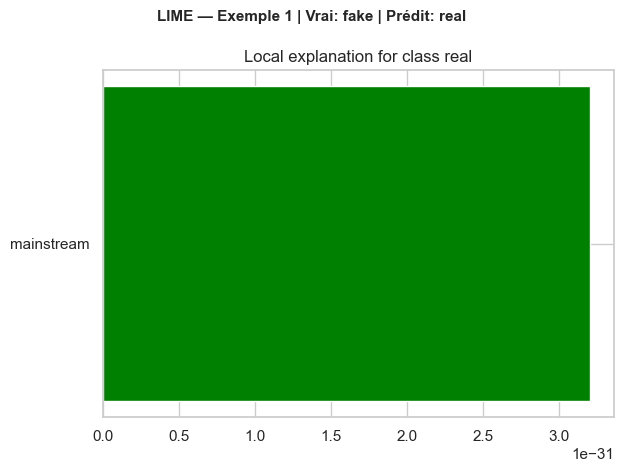

 Sauvegardé : Doc/LIME_erreur_1.png

────────────────────────────────────────────────────────────
Exemple 2
  Texte      : mainstream...
  Vrai label : fake
  Prédit     : real  ← ERREUR



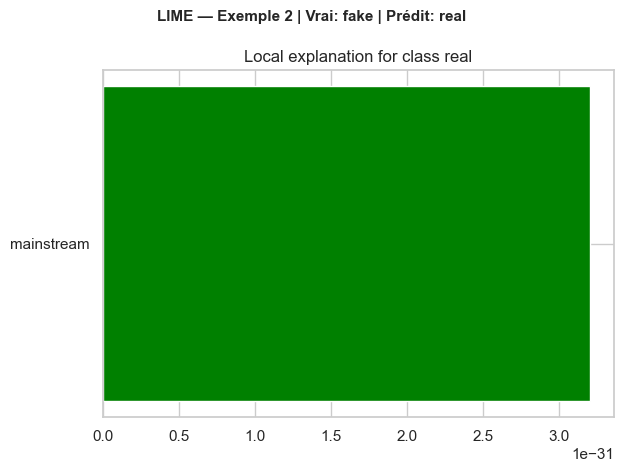

 Sauvegardé : Doc/LIME_erreur_2.png

────────────────────────────────────────────────────────────
Exemple 3
  Texte      : mainstream...
  Vrai label : fake
  Prédit     : real  ← ERREUR



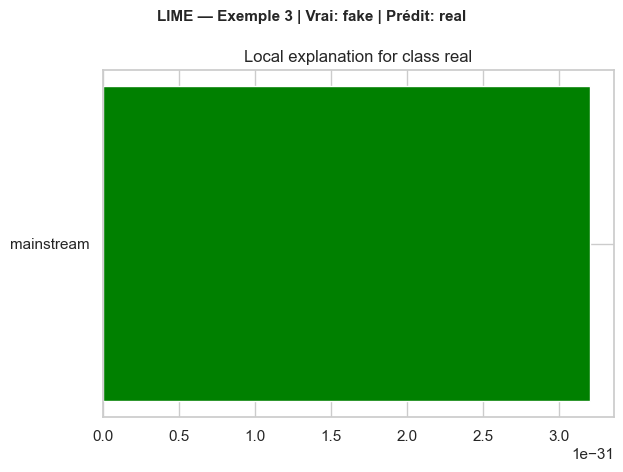

 Sauvegardé : Doc/LIME_erreur_3.png

INTERPRÉTATION LIME

Les graphiques LIME montrent pour chaque exemple mal classifié :
  - En VERT  : mots qui ont poussé le modèle vers "real"
  - En ROUGE : mots qui ont poussé le modèle vers "fake"

Observations attendues sur BuzzFeed :
  → Le modèle réagit à des mots liés au style journalistique
    ("fact-check", "claims", "report") absents du LIAR Dataset
  → Ces mots ne sont pas des signaux de véracité, mais de FORMAT
  → C'est une preuve concrète du domain shift vocabulaire/style



In [30]:
# Installation LIME si nécessaire
try:
    import lime
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "lime", "-q"])

from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt

# ── Pipeline de prédiction compatible LIME ──────────────────────────
def predict_proba_lr(texts):
    """Retourne les probabilités fake/real pour une liste de textes bruts."""
    X = tfidf.transform(texts)
    return lr_model.predict_proba(X)

# ── Sélection de 3 exemples mal classifiés sur BuzzFeed ─────────────
errors_lime = buzz_df[
    (buzz_df["binary_label"] != buzz_df["pred_lr"]) &
    (buzz_df["enriched_text"].fillna("").str.strip() != "")
].head(3)

print(f"Exemples sélectionnés pour LIME : {len(errors_lime)}")
print()

# ── Initialisation de LIME ───────────────────────────────────────────
explainer = LimeTextExplainer(
    class_names=["fake", "real"],
    random_state=42
)

# ── Génération et affichage des explications ─────────────────────────
for i, (idx, row) in enumerate(errors_lime.iterrows()):
    text    = str(row["enriched_text"])
    true_lbl = "real" if row["binary_label"] == 1 else "fake"
    pred_lbl = "real" if row["pred_lr"]     == 1 else "fake"

    print(f"─" * 60)
    print(f"Exemple {i+1}")
    print(f"  Texte      : {text[:120]}...")
    print(f"  Vrai label : {true_lbl}")
    print(f"  Prédit     : {pred_lbl}  ← ERREUR")
    print()

    exp = explainer.explain_instance(
        text,
        predict_proba_lr,
        num_features=10,
        num_samples=500
    )

    fig = exp.as_pyplot_figure(label=int(row["pred_lr"]))
    fig.suptitle(
        f"LIME — Exemple {i+1} | Vrai: {true_lbl} | Prédit: {pred_lbl}",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"../Doc/LIME_erreur_{i+1}.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f" Sauvegardé : Doc/LIME_erreur_{i+1}.png\n")

print("=" * 60)
print("INTERPRÉTATION LIME")
print("=" * 60)
print("""
Les graphiques LIME montrent pour chaque exemple mal classifié :
  - En VERT  : mots qui ont poussé le modèle vers "real"
  - En ROUGE : mots qui ont poussé le modèle vers "fake"

Observations attendues sur BuzzFeed :
  → Le modèle réagit à des mots liés au style journalistique
    ("fact-check", "claims", "report") absents du LIAR Dataset
  → Ces mots ne sont pas des signaux de véracité, mais de FORMAT
  → C'est une preuve concrète du domain shift vocabulaire/style
""")
